# 99 — Trader BT Explorer (change `TRADER_PATH`, re-run all)

In [8]:
# === CHANGE THIS ONE LINE ===
# TRADER_PATH = "src/trader.py"
TRADER_PATH = "docs/round_3/strategies/snapshots/v10_trader.py"

# Other options to swap in:
#   "data/teammate_logs/ian/464669.py"
#   "data/teammate_logs/ian2/471212.py"
#   "docs/round_3/strategies/snapshots/v2_trader.py"
#   "docs/round_3/strategies/snapshots/v4_trader.py"
#   "docs/round_3/strategies/snapshots/v6_trader.py"
#   "docs/round_3/strategies/snapshots/v7_trader.py"
#   "docs/round_3/strategies/snapshots/v8_trader.py"

from pathlib import Path
import re, subprocess, io, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PLOTS_DIR = ROOT / "docs" / "round_3" / "research" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print("Trader:", TRADER_PATH)


Trader: docs/round_3/strategies/snapshots/v10_trader.py


In [9]:
# Run backtest (3-day, merged PnL)
cmd = [str(ROOT / "venv/bin/prosperity4btest"), "cli", TRADER_PATH, "3", "--merge-pnl", "--no-progress"]
print("Running:", " ".join(cmd))
proc = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
stdout = proc.stdout + proc.stderr
print(stdout[-1200:])

m = re.search(r"saved backtest results to (\S+\.log)", stdout)
assert m, "Could not find saved log path in stdout"
log_path = ROOT / m.group(1)
print("Log:", log_path)

# Capture risk-metrics block printed by the backtester
metrics_stdout = {}
for line in stdout.splitlines():
    mm = re.match(r"\s+(\w+):\s+([\-0-9,\.infa]+)", line)
    if mm and mm.group(1) in {"final_pnl","sharpe_ratio","annualized_sharpe","sortino_ratio","max_drawdown_abs","max_drawdown_pct","calmar_ratio"}:
        v = mm.group(2).replace(",", "")
        try: metrics_stdout[mm.group(1)] = float(v)
        except ValueError: metrics_stdout[mm.group(1)] = v
print(metrics_stdout)


Running: /Users/bensinek/Documents/Coding/Prosperity4/venv/bin/prosperity4btest cli docs/round_3/strategies/snapshots/v10_trader.py 3 --merge-pnl --no-progress

VEV_5000: 11,534
VEV_5100: 11,986
VEV_5200: 11,116
VEV_5300: 9,538
VEV_5400: 0
VEV_5500: 0
VEV_6000: 0
VEV_6500: 0
Total profit: 117,592

Backtesting /Users/bensinek/Documents/Coding/Prosperity4/docs/round_3/strategies/snapshots/v10_trader.py on round 3 day 1
HYDROGEL_PACK: 21,566
VELVETFRUIT_EXTRACT: 35,581
VEV_4000: 0
VEV_4500: 0
VEV_5000: 18,112
VEV_5100: 19,854
VEV_5200: 20,066
VEV_5300: 20,680
VEV_5400: 0
VEV_5500: 0
VEV_6000: 0
VEV_6500: 0
Total profit: 135,859

Backtesting /Users/bensinek/Documents/Coding/Prosperity4/docs/round_3/strategies/snapshots/v10_trader.py on round 3 day 2
HYDROGEL_PACK: 34,820
VELVETFRUIT_EXTRACT: 22,457
VEV_4000: 0
VEV_4500: 0
VEV_5000: 11,952
VEV_5100: 13,508
VEV_5200: 13,812
VEV_5300: 11,705
VEV_5400: 0
VEV_5500: 0
VEV_6000: 0
VEV_6500: 0
Total profit: 108,254

Profit summary:
Round 3 day 0: 

In [10]:
# Parse activities log into DataFrame
text = log_path.read_text()
start = text.index("Activities log:") + len("Activities log:")
end = text.index("Trade History:")
csv_block = text[start:end].strip()
df = pd.read_csv(io.StringIO(csv_block), sep=";")
print(df.shape, "rows;", df["product"].unique())

# Build a global tick (merged across days) ordered by (day, timestamp)
df = df.sort_values(["day","timestamp"]).reset_index(drop=True)
# --merge-pnl already produces sequential timestamps across days, so use them directly
df["global_t"] = df["timestamp"]

# Per-tick total PnL (sum across products)
total = df.groupby("global_t")["profit_and_loss"].sum().sort_index()
# Per-product PnL trajectory
per_prod = df.pivot_table(index="global_t", columns="product", values="profit_and_loss", aggfunc="sum").sort_index().ffill().fillna(0)

final_pnl = float(total.iloc[-1])
running_max = total.cummax()
dd = total - running_max
max_dd_abs = float(-dd.min())
max_dd_idx = dd.idxmin()
ret = total.diff().fillna(0)
sharpe = float(ret.mean() / (ret.std() + 1e-12))
calmar = final_pnl / max_dd_abs if max_dd_abs > 0 else float("inf")
max_dd_pct = max_dd_abs / max(running_max.max(), 1) * 100

summary = {
    "final_pnl": metrics_stdout.get("final_pnl", final_pnl),
    "sharpe_ratio": metrics_stdout.get("sharpe_ratio", sharpe),
    "max_drawdown_abs": metrics_stdout.get("max_drawdown_abs", max_dd_abs),
    "max_drawdown_pct": metrics_stdout.get("max_drawdown_pct", max_dd_pct),
    "calmar_ratio": metrics_stdout.get("calmar_ratio", calmar),
}
print(summary)


(360000, 17) rows; <StringArray>
[      'HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT',            'VEV_4000',
            'VEV_4500',            'VEV_5000',            'VEV_5100',
            'VEV_5200',            'VEV_5300',            'VEV_5400',
            'VEV_5500',            'VEV_6000',            'VEV_6500']
Length: 12, dtype: str
{'final_pnl': 361705.0, 'sharpe_ratio': 8.5867, 'max_drawdown_abs': 42668.0, 'max_drawdown_pct': 20.1129, 'calmar_ratio': 8.4771}


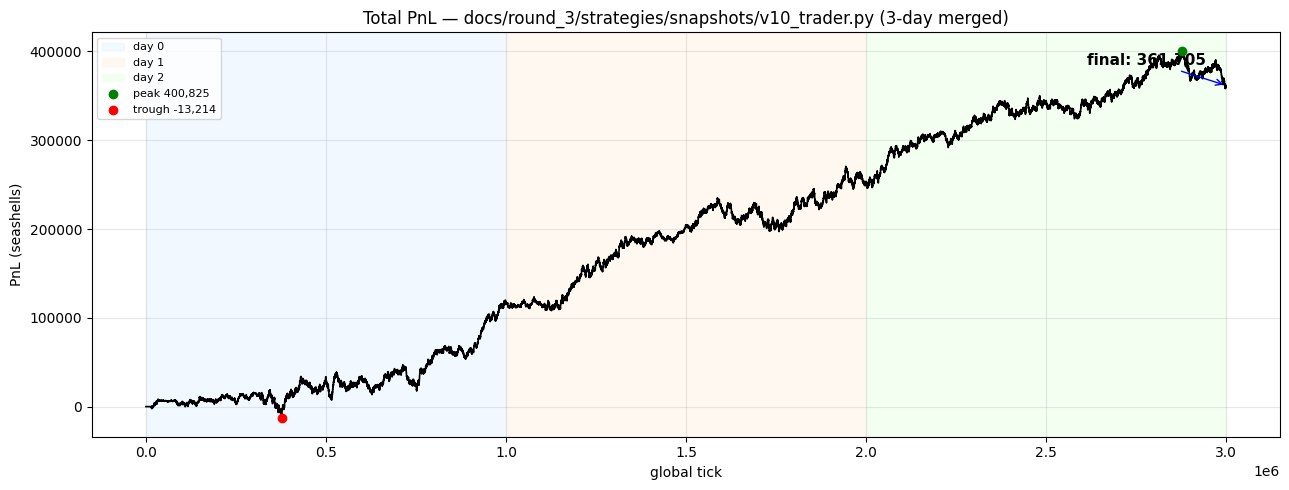

In [11]:
# Plot 1 — Total PnL over full 3 days, day-shaded, peak/trough/final marked
fig, ax = plt.subplots(figsize=(13,5))
ax.plot(total.index, total.values, color="black", lw=1.2)
days = sorted(df["day"].unique())
colors = ["#e8f4ff","#fff4e8","#ecffe8"]
for i,d in enumerate(days):
    mask = df["day"]==d
    lo = df.loc[mask,"global_t"].min(); hi = df.loc[mask,"global_t"].max()
    ax.axvspan(lo, hi, color=colors[i%3], alpha=0.6, label=f"day {d}")
peak_t = total.idxmax(); peak_v = total.max()
trough_t = total.idxmin(); trough_v = total.min()
ax.scatter([peak_t],[peak_v], color="green", zorder=5, label=f"peak {peak_v:,.0f}")
ax.scatter([trough_t],[trough_v], color="red", zorder=5, label=f"trough {trough_v:,.0f}")
ax.annotate(f"final: {final_pnl:,.0f}", xy=(total.index[-1], final_pnl),
            xytext=(-100,15), textcoords="offset points", fontsize=11, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="blue"))
ax.set_title(f"Total PnL — {TRADER_PATH} (3-day merged)")
ax.set_xlabel("global tick"); ax.set_ylabel("PnL (seashells)")
ax.grid(alpha=0.3); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "99_total_pnl.png", dpi=110)
plt.show()


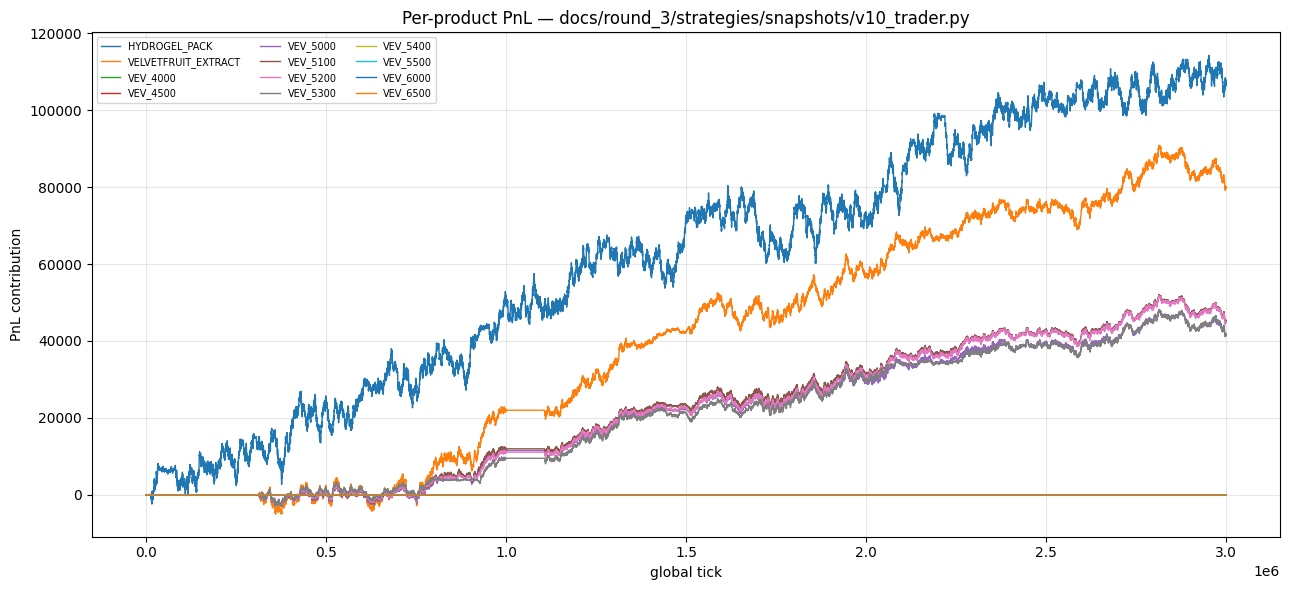

In [12]:
# Plot 2 — Per-product PnL trajectory
fig, ax = plt.subplots(figsize=(13,6))
for col in per_prod.columns:
    ax.plot(per_prod.index, per_prod[col].values, lw=1, label=col)
ax.set_title(f"Per-product PnL — {TRADER_PATH}")
ax.set_xlabel("global tick"); ax.set_ylabel("PnL contribution")
ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=3, loc="upper left")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "99_per_product_pnl.png", dpi=110)
plt.show()


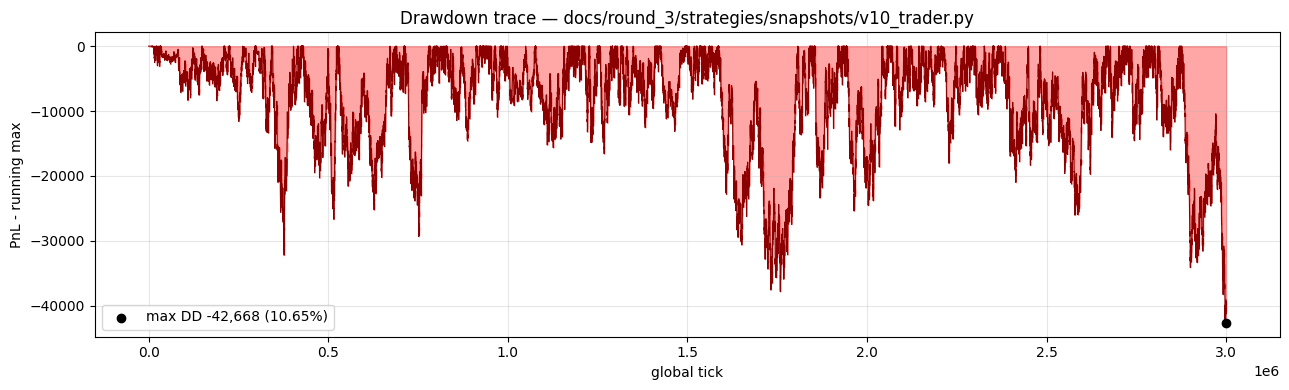

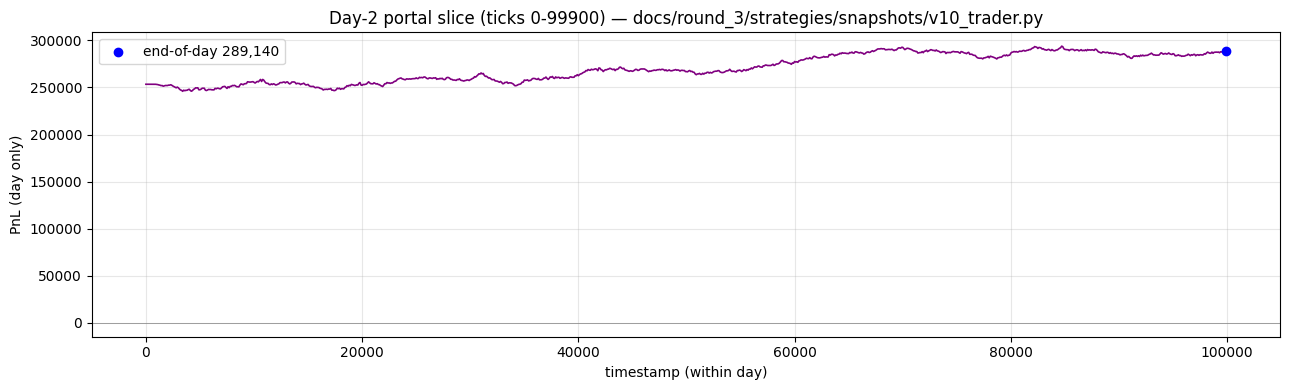

In [13]:
# Plot 3 — Drawdown trace
fig, ax = plt.subplots(figsize=(13,4))
ax.fill_between(dd.index, dd.values, 0, color="red", alpha=0.35)
ax.plot(dd.index, dd.values, color="darkred", lw=0.8)
ax.scatter([max_dd_idx],[dd.min()], color="black", zorder=5,
           label=f"max DD {dd.min():,.0f} ({max_dd_pct:.2f}%)")
ax.set_title(f"Drawdown trace — {TRADER_PATH}")
ax.set_xlabel("global tick"); ax.set_ylabel("PnL - running max")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "99_drawdown.png", dpi=110)
plt.show()

# Plot 4 — Day-2 portal slice (ticks 0..99900) — what IMC portal shows
day2 = sorted(df["day"].unique())[-1]
d2 = df[df["day"]==day2].copy()
# With --merge-pnl, timestamps increase across days; rebase to per-day local 0..999900
d2["local_t"] = d2["timestamp"] - d2["timestamp"].min()
d2_total = d2.groupby("local_t")["profit_and_loss"].sum().sort_index()
d2_total = d2_total[(d2_total.index >= 0) & (d2_total.index <= 99900)]
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(d2_total.index, d2_total.values, color="purple", lw=1.2)
ax.axhline(0, color="grey", lw=0.5)
ax.scatter([d2_total.index[-1]],[d2_total.iloc[-1]], color="blue", zorder=5,
           label=f"end-of-day {d2_total.iloc[-1]:,.0f}")
ax.set_title(f"Day-{day2} portal slice (ticks 0-99900) — {TRADER_PATH}")
ax.set_xlabel("timestamp (within day)"); ax.set_ylabel("PnL (day only)")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "99_day2_portal_slice.png", dpi=110)
plt.show()


In [14]:
# Summary table + reference comparison if applicable
print(f"\n{'='*60}\nSUMMARY  ({TRADER_PATH})\n{'='*60}")
rows = [
    ("Final PnL",         f"{summary['final_pnl']:,.0f}"),
    ("Sharpe (per-tick)", f"{summary['sharpe_ratio']:.4f}"),
    ("Max Drawdown abs",  f"{summary['max_drawdown_abs']:,.0f}"),
    ("Max Drawdown %",    f"{summary['max_drawdown_pct']:.2f}%"),
    ("Calmar",            f"{summary['calmar_ratio']:.4f}"),
]
for k,v in rows: print(f"  {k:<22} {v:>15}")

if TRADER_PATH == "src/trader.py":
    ref = {"final_pnl":119_578, "sharpe_ratio":2.35, "max_drawdown_abs":19_696,
           "max_drawdown_pct":9.91, "calmar_ratio":6.07}
    print(f"\n{'-'*60}\nReference (docs/round_3/strategies/v8_hg_takemaker.md)\n{'-'*60}")
    for k in ("final_pnl","sharpe_ratio","max_drawdown_abs","max_drawdown_pct","calmar_ratio"):
        cur = float(summary[k]); r = ref[k]
        delta = cur - r
        print(f"  {k:<22}  cur={cur:>12,.2f}   ref={r:>12,.2f}   delta={delta:+,.2f}")



SUMMARY  (docs/round_3/strategies/snapshots/v10_trader.py)
  Final PnL                      361,705
  Sharpe (per-tick)               8.5867
  Max Drawdown abs                42,668
  Max Drawdown %                  20.11%
  Calmar                          8.4771
